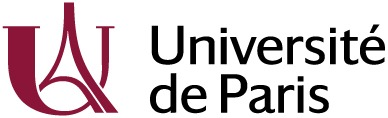
## M2 VMI - TP AD: Object detection using CNNs - Facemasks

Sylvain Lobry, 2020

Pre-requisite: having a google account (sorry about that...)

In this lab we are going to train a model to detect if people are (correctly) wearing face masks. As data, we will use [one of the datasets available on Kaggle](https://www.kaggle.com/andrewmvd/face-mask-detection).

## 1) Loading the data
You can get the data [from kaggle](https://www.kaggle.com/andrewmvd/face-mask-detection) directly, or through my [Google Drive](https://drive.google.com/drive/folders/1oxP0ept0pmOgjl1BbYaUj9Cf_X7FnI2A?usp=sharing). Then, copy it to your drive.

Now, you need to mount your drive in this VM. This is done by executing the following two lines. You will need to authorize google collab to access to your drive (it will ask you to open a link and give you a confirmation code that you will have to copy on the text field bellow).

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Now find the path to your data:

In [11]:
import os

print(len(os.listdir('/content/drive/My Drive/TPFacemask/Data/annotations')))
print(len(os.listdir('/content/drive/My Drive/TPFacemask/Data/images')))

853
853


In [12]:
data_folder = '/content/drive/My Drive/TPFacemask/Data'
root_folder = '/content/drive/My Drive/TPFacemask/'

## 2) Understanding the data format
In the data folder, you have 2 sub-folders:


1.   images
2.   annotations

The images are in the png format, and the annotations are in the xml format.

**Réponse 1:** Open an xml file, and try to understand the information it contains and describe it. From this xml, can you guess what bounding box format is used in this dataset?

Let's parse one XML:

In [13]:
import os
import xml.etree.ElementTree as ET

def get_objects(xml_file):
  annotation = ET.parse(xml_file)
  root = annotation.getroot()

  objects = []
  for obj in root.findall('object'):
    new_object = {'name': obj.find('name').text}
    bbox = obj.find('bndbox')

    xmin = int(bbox.find('xmin').text)
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)

    new_object['bbox'] =[xmin, ymin, xmax, ymax]
    objects.append(new_object)
  return objects



data = get_objects('/content/drive/My Drive/TPFacemask/Data/annotations/maksssksksss0.xml')
print(data)

[{'name': 'without_mask', 'bbox': [79, 105, 109, 142]}, {'name': 'with_mask', 'bbox': [185, 100, 226, 144]}, {'name': 'without_mask', 'bbox': [325, 90, 360, 141]}]


**Réponse 1**
The XML file contains information about the corresponding image and the objects detected in it. For example, the annotation file `maksssksksss0.xml` contains three annotated objects.

Each object has a class name (`with_mask` or `without_mask`) and a bounding box. For example, the first object is labeled `without_mask` and has the bounding box `[79, 105, 109, 142]`.

The bounding box format is:

`[xmin, ymin, xmax, ymax]`

where `(xmin, ymin)` represents the top-left corner of the bounding box and `(xmax, ymax)` represents the bottom-right corner.

Therefore, the dataset uses corner coordinates to represent bounding boxes.


and show the bounding boxes on one image:

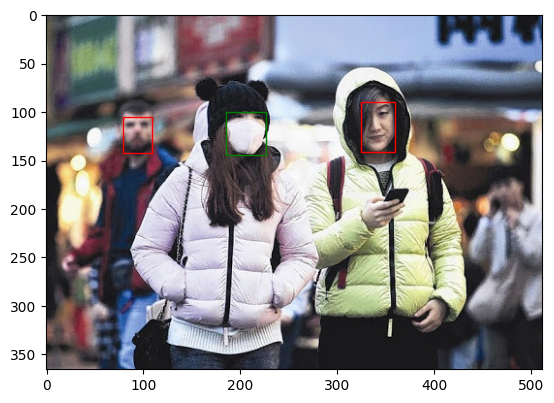

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Color of the bounding boxes (depending on the class)
classes_color = {'with_mask':'g', 'without_mask':'r', 'mask_weared_incorrect':'tab:orange'}
classes_index = {'with_mask':1, 'without_mask':2, 'mask_weared_incorrect':3} #Careful!! 0 is for background!!

def show_bboxes(image, objects):
  fig,ax = plt.subplots(1)
  ax.imshow(image)

  for annotation in objects:
    xmin, ymin, xmax, ymax = annotation['bbox']
    rect = patches.Rectangle((xmin,ymin), (xmax-xmin), (ymax-ymin), linewidth=1, edgecolor=classes_color[annotation['name']], facecolor='none')
    ax.add_patch(rect)
  plt.show()

index = 0 #TODO: choose a relevant example
objects = get_objects(os.path.join(data_folder, 'annotations', 'maksssksksss' + str(index) + '.xml'))
image = plt.imread(os.path.join(data_folder, 'images', 'maksssksksss' + str(index) + '.png'))
show_bboxes(image, objects)

We selected the first image of the dataset (index = 0) and visualized its annotations. The image contains three annotated faces: two people without a mask and one person wearing a mask. The bounding boxes are correctly displayed according to the coordinates extracted from the XML annotation file.


**Question 2:** We are going to learn from this data. By looking at it, can you find possible biases in it?

**Réponse 2:**

There are several possible sources of bias in the dataset. First, the three classes (`with_mask`, `without_mask`, and `mask_weared_incorrect`) may not be equally represented. This could make the model favor the most frequent classes.

There can also be variations in the image conditions, such as lighting, image quality, background, face size, and viewing angle. Some types of people or situations may also be more frequently represented than others.

Therefore, the model may learn characteristics related to the dataset or its context instead of only learning the visual characteristics of the masks. The class distribution should be checked to determine whether there is an actual imbalance.


## 3) Creating the dataset class

Now, we need to create a class derived from pytorch's Dataset class able to understand or data format. Since the datasert is not too big, we can load it entirely in RAM.

In [36]:
from torch.utils.data import Dataset
import torchvision.transforms as T
from tqdm.notebook import tqdm
from PIL import Image

class FaceMaskDataset(Dataset):
  def __init__(self, img_folder, annotation_folder, indexes, conversion=T.ToTensor()):
    self.conversion = conversion

    self.dataset = []
    for index in tqdm(indexes):
      sample = {}
      sample['image'] = sample['image'] = Image.open(os.path.join(img_folder, 'images', 'maksssksksss' + str(index) + '.png')).convert('RGB') # Load the image
      sample['objects'] = get_objects(os.path.join(annotation_folder, 'annotations', 'maksssksksss' +  str(index) + '.xml')) # Load the objects using the function we created before.
      sample['id'] = index
      self.dataset.append(sample)

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    target = {'boxes': [], 'labels': []}
    for obj in self.dataset[idx]['objects']:
      target["boxes"].append(obj['bbox'])
      target['labels'].append(classes_index[obj['name']])

    target["boxes"] = torch.as_tensor(target["boxes"], dtype=torch.float32)
    target["labels"] = torch.as_tensor(target['labels'], dtype=torch.int64)
    target["image_id"] = torch.tensor([self.dataset[idx]['id']])

    img = self.dataset[idx]['image']
    if self.conversion is not None:
      img = self.conversion(img)
    return img, target

And we can create the datasets.

**Question 3:** What is the total number of samples that we have? Does that seem sufficient to train a model? What strategy could we use for training?

**Réposense 3: What is the total number of samples that we have? Is this number sufficient? How should we train the model?**

The dataset contains 853 images, with one corresponding XML annotation file for each image.

This is a relatively small dataset for training an object detection model from scratch. Therefore, several strategies can be considered.

A first possibility is to split the data into training, validation, and test sets, for example 60% for training, 20% for validation, and 20% for testing. This is the strategy used in this notebook.

Because the dataset is relatively small, K-Fold Cross-Validation is also an interesting strategy. The training data can be divided into several folds, and each fold can be used once for validation while the other folds are used for training. This allows the available data to be used more efficiently and provides a more robust estimate of the model's performance.

Another possibility is to use data augmentation to increase the variability of the training images. Finally, transfer learning can be used by starting from a model pre-trained on a larger dataset and fine-tuning it on the face-mask detection task.

In [16]:
import os

print(len(os.listdir('/content/drive/My Drive/TPFacemask/Data/annotations')))
print(len(os.listdir('/content/drive/My Drive/TPFacemask/Data/images')))

train_split_percentage =0.6 #TODO: Choose
val_split_percentage = 0.2 #TODO: Choose
test_split_percentage = 0.2 #TODO: Choose
size_of_the_dataset = 853 #TODO

indexes = list(range(size_of_the_dataset))
print(indexes)

853
853
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 2

In [37]:
import random
import torch



train_split_percentage =0.6 #TODO: Choose
val_split_percentage = 0.2 #TODO: Choose
test_split_percentage = 0.2 #TODO: Choose
size_of_the_dataset = 853 #TODO

indexes = list(range(size_of_the_dataset))
random.shuffle(indexes)

train_indexes = indexes[:int(train_split_percentage*len(indexes))]
val_indexes = indexes[int(train_split_percentage*len(indexes)):int((train_split_percentage + val_split_percentage)*len(indexes))]
test_indexes = indexes[int((train_split_percentage + val_split_percentage)*len(indexes)):]

print(f"Effective train split = {len(train_indexes)/len(indexes)*100}%")
print(f"Effective val split = {len(val_indexes)/len(indexes)*100}%")
print(f"Effective test split = {len(test_indexes)/len(indexes)*100}%", flush=True)

# From https://github.com/pytorch/vision/blob/ce342580f3ae3f937fa5389c48b82a827b4804df/references/detection/utils.py#L235
def collate_fn(batch):
    return tuple(zip(*batch))



def get_transform(train):
    transforms = []
    transforms.append(T.ToTensor())
    #TODO: potentially add data augmentation
    return T.Compose(transforms)

batch_size = 2
print("Loading training set")
train_dataset = FaceMaskDataset(data_folder, data_folder, train_indexes, conversion=get_transform(True))
print("Loading validation set")
val_dataset = FaceMaskDataset(data_folder, data_folder, val_indexes, conversion=get_transform(False))
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=collate_fn)

Effective train split = 59.90621336459554%
Effective val split = 20.046893317702228%
Effective test split = 20.046893317702228%
Loading training set


  0%|          | 0/511 [00:00<?, ?it/s]

Loading validation set


  0%|          | 0/171 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


One thing which is always important is to check the data. At the sample size, we have already seen how to check that we understood the data format, and checked a few samples for corectness. At a larger scale, it is often a good idea to check the labels' distribution.

**Question 4:** Propose and implement a methodology to check the labels' distribution. Discuss your findings.

Counter({'with_mask': 3232, 'without_mask': 717, 'mask_weared_incorrect': 123})


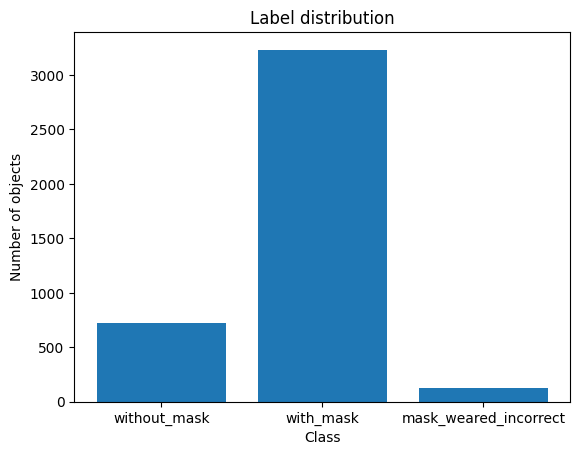

In [27]:
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches

label_counts = Counter()

for index in range(853):
    xml_file = os.path.join(
        data_folder,
        'annotations',
        'maksssksksss' + str(index) + '.xml'
    )

    objects = get_objects(xml_file)

    for obj in objects:
        label_counts[obj['name']] += 1

print(label_counts)


import matplotlib.pyplot as plt

plt.bar(label_counts.keys(), label_counts.values())

plt.xlabel("Class")
plt.ylabel("Number of objects")
plt.title("Label distribution")

plt.show()

**Réponse 4:**

We counted the number of annotated objects for each class in the dataset. The results are:

with_mask: 3232 objects
without_mask: 717 objects
mask_weared_incorrect: 123 objects

In total, there are 4072 annotated objects in the 853 images.

The distribution is highly imbalanced. The with_mask class represents about 79.4% of the annotated objects, while without_mask represents about 17.6% and mask_weared_incorrect only about 3.0%.

Therefore, the with_mask class is strongly over-represented, while mask_weared_incorrect is the minority class. This class imbalance is a potential source of bias and should be taken into account when training and evaluating the model.

## 4) Defining the model

For this project, we propose to take a pre-trained Faster R-CNN.

Faster R-CNN is an extension of R-CNN seen during the lecture. Conceptually, both methods are very similar. The main improvements of Faster R-CNN is to share convolutional features between the region proposal part and the actual object detection part. To know more, you can read [the original article](https://arxiv.org/pdf/1506.01497.pdf).

This network has been pre-trained on [MS-COCO](https://cocodataset.org/#home), which is a classical large-scale object detection dataset.


In [38]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

#load Faster R-CNN pre-trained on COCO dataset
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
#Change the classifier head with a new one:
in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 4 #(3 + background)
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 5) Training

Now that we have both the architecture and the data, we can train our model.

You should enable GPU in your collab at this point. To do so go to runtime -> Change runtime type -> Hardware accelerator and select "GPU";

In [39]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

model = model.to(device)

Using device: cpu


We can now define the training loop.

**Question 5:** How did you choose your hyper-parameters?

In [ ]:
number_epochs = 10 #TODO: Choose
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.01)

train_loss = []
val_loss = []

for epoch in range(number_epochs):
  print(f"Starting epoch {epoch}")

  if epoch > 0:
    plt.figure()

  # =========================
  # Training
  # =========================
  model.train()
  train_loss.append(0)

  for images, labels in tqdm(train_loader):

    images = list(image.to(device) for image in images)
    labels = [{k: v.to(device) for k, v in t.items()} for t in labels]

    loss_dict = model(images, labels)

    losses = sum(loss for loss in loss_dict.values())

    optimizer.zero_grad()
    losses.backward()
    optimizer.step()

    train_loss[epoch] += losses.cpu().data

  train_loss[epoch] /= len(train_dataset)

  if epoch > 0:
    train_plt, = plt.plot(train_loss, label='Train')

  # =========================
  # Validation
  # =========================
  val_loss.append(0)

  with torch.no_grad():
    model.train()

    for images, labels in tqdm(val_loader):

      images = list(image.to(device) for image in images)
      labels = [{k: v.to(device) for k, v in t.items()} for t in labels]

      loss_dict = model(images, labels)

      losses = sum(loss for loss in loss_dict.values())

      val_loss[epoch] += losses.cpu().item()

    val_loss[epoch] /= len(val_dataset)

  if epoch > 0:
    val_plt, = plt.plot(val_loss, label='Validation')
    plt.legend(handles=[train_plt, val_plt])
    plt.show()

  # =========================
  # Save model
  # =========================
  torch.save(
      model.state_dict(),
      os.path.join(root_folder, 'model_epoch' + str(epoch) + '.pt')
  )

Starting epoch 0


  0%|          | 0/256 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 6) Evaluate the model
First, we need to load the test set:

In [ ]:
print("Loading test set")
test_dataset = FaceMaskDataset(os.path.join(data_folder, 'images'), os.path.join(data_folder, 'annotations'), test_indexes, conversion=get_transform(False))
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=collate_fn)


**TODO** Now you need to re-use what you have seen before to do the evaluation (both with losses and classical metrics). You need to discuss it.

Good luck!